## To do

* Use consistently the DR9 imaging random catalog for random galaxies and coverage percentage

In [1]:
## Folders repo_dir(), data_dir(), plot_dir()
import sys
sys.path.insert(0, '/global/homes/z/zzhang13/DESI/')
from setup import *

In [2]:
from scipy.stats import kde
import h5py
import astropy.io.fits as fits
import csv
import pandas as pd
import numpy as np
import healpy as hp
import tables
import pickle
import os
from astropy.table import Table
from astropy.coordinates import SkyCoord
from tqdm import tqdm
from astropy.io import ascii
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import incredible as cr
from scipy.special import erf
from scipy import stats
import scipy.optimize as opt
from scipy import stats
import scipy.optimize as opt
import emcee
import tqdm
import pickle
from astropy import table
from astropy.table import Table, join, unique
from specutils import SpectralRegion
from scipy.interpolate import BSpline, make_interp_spline, UnivariateSpline

from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
import numpy as np
import astropy.units as u
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18
from astropy.cosmology import z_at_value
cosmo = Planck18

## Functions for computing spectroscopic richness and profiles
from tools.projection_functions import *


##Plotting
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt

from astropy.io import ascii

plot_params = {

'axes.linewidth': 1.25,
'xtick.major.width': 1, 'ytick.major.width': 1,
'xtick.minor.width': 1, 'ytick.minor.width': 1,
'xtick.major.size': 12, 'ytick.major.size': 12,
'xtick.labelsize': 12, 'ytick.labelsize': 12,
'xtick.direction': 'in', 'ytick.direction': 'in',
'xtick.major.pad': 6, 'xtick.minor.pad': 6,
'figure.constrained_layout.use': True,
#'text.usetex': True,
'font.family': 'Serif',
'font.size': 14,
'legend.fontsize': 11
    
}
plt.rcParams.update(plot_params)

## Analyze the DR9 Catalog

In [ ]:
dr9_photoz_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/sweep/9.0/'
test_file = 'sweep-130p050-140p055.fits'
fname = dr9_photoz_dir + test_file

In [ ]:
hdul = fits.open(fname)

# List HDUs
#hdul.info()

# Read the main table (usually HDU 1)
data = hdul[1].data

print(data.dtype.names[:10])  # column names
print(len(data))              # number of objects

In [ ]:
data.dtype

In [ ]:
from astropy.io import fits

with fits.open(fname, memmap=True) as hdul:
    tab = hdul[1].data
    ra   = tab["RA"]
    dec  = tab["DEC"]
    flux_g = tab["FLUX_G"]
    flux_r = tab["FLUX_R"]
    flux_z = tab["FLUX_Z"]


In [ ]:
## Convert to maggies
import numpy as np

def nanomaggies_to_mag(flux):
    mag = 22.5 - 2.5 * np.log10(flux)
    mag[flux <= 0] = np.nan
    return mag

g = nanomaggies_to_mag(flux_g)
r = nanomaggies_to_mag(flux_r)
z = nanomaggies_to_mag(flux_z)

gr = g - r
rz = r - z

In [ ]:
mw_g = tab["MW_TRANSMISSION_G"]
mw_r = tab["MW_TRANSMISSION_R"]
mw_z = tab["MW_TRANSMISSION_Z"]

g_corr = nanomaggies_to_mag(flux_g / mw_g)
r_corr = nanomaggies_to_mag(flux_r / mw_r)
z_corr = nanomaggies_to_mag(flux_z / mw_z)

### Color Information

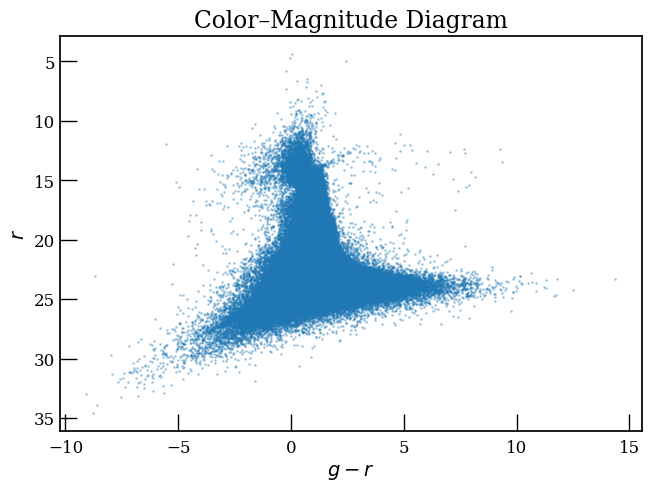

In [9]:
color = g_corr - r_corr
mag   = r_corr

plt.figure()
plt.scatter(color, mag, s=1, alpha=0.3)
plt.gca().invert_yaxis()
plt.xlabel(r"$g - r$")
plt.ylabel(r"$r$")
plt.title("Color–Magnitude Diagram")
plt.show()

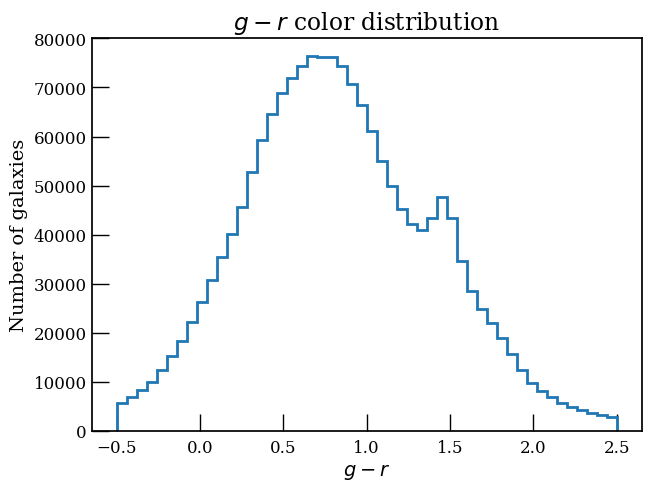

In [10]:
import numpy as np
import matplotlib.pyplot as plt

color_gr = g_corr - r_corr

# basic quality cut
good = (
    np.isfinite(color_gr) &
    (color_gr > -0.5) & (color_gr < 2.5)
)

plt.figure()
plt.hist(color_gr[good], bins=50, histtype="step", linewidth=2)
plt.xlabel(r"$g - r$")
plt.ylabel("Number of galaxies")
plt.title(r"$g-r$ color distribution")
plt.show()

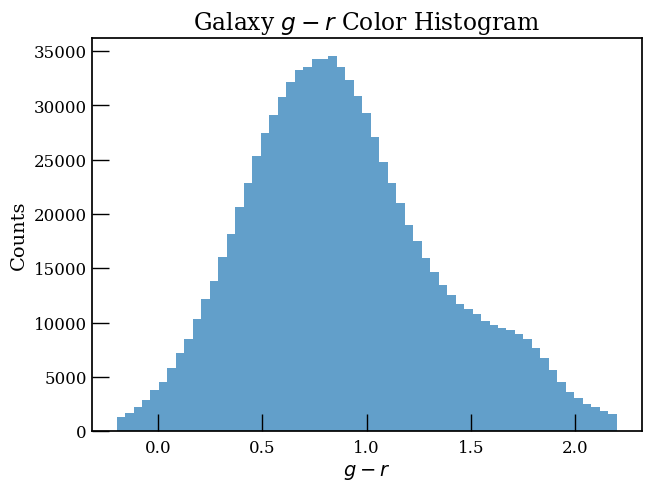

In [11]:
good = (
    np.isfinite(color_gr) &
    (r_corr < 23.5) &                  # Legacy depth
    (tab["FLUX_IVAR_G"] > 0) &
    (tab["FLUX_IVAR_R"] > 0) &
    (tab["TYPE"] != "PSF")              # galaxies only
)

plt.figure()
plt.hist(
    color_gr[good],
    bins=np.linspace(-0.2, 2.2, 60),
    histtype="stepfilled",
    alpha=0.7
)
plt.xlabel(r"$g - r$")
plt.ylabel("Counts")
plt.title("Galaxy $g-r$ Color Histogram")
plt.show()

## Sweep through the RA and DEC in mollviewe plot

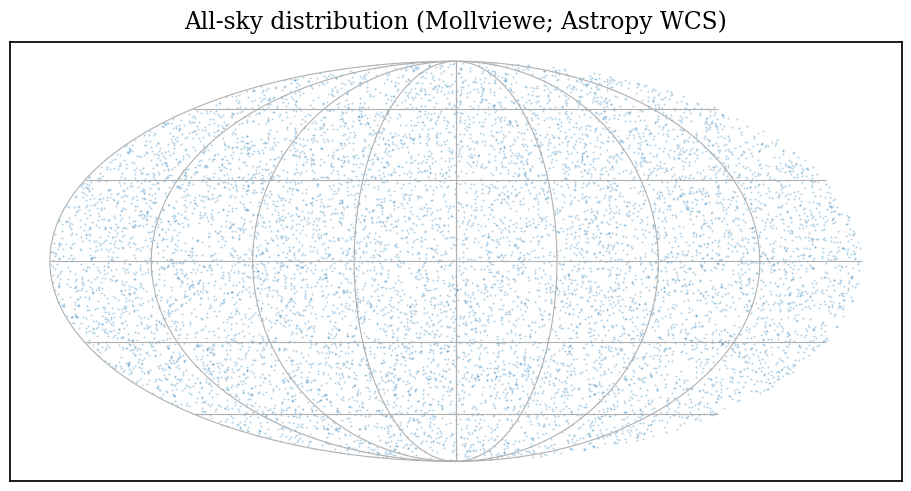

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

# --- Inputs ---
import numpy as np
N = 10000
# RA uniform in [0, 360)
ra = np.random.uniform(0.0, 360.0, N)

# Dec uniform in sin(dec)
u_rand = np.random.uniform(-1.0, 1.0, N)
dec = np.degrees(np.arcsin(u_rand))

coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")

# --- Build an all-sky WCS with an Aitoff projection ---
# Choose a pixel grid size for the projection canvas
nx, ny = 1600, 800  # higher = smoother (and heavier)

w = WCS(naxis=2)
#w.wcs.ctype = ["RA---AIT", "DEC--AIT"]  # Aitoff projection
w.wcs.ctype = ["RA---MOL", "DEC--MOL"] ##mollviewe
w.wcs.crval = [0.0, 0.0]               # reference sky position (RA,Dec) in deg
w.wcs.crpix = [nx/2.0, ny/2.0]         # reference pixel (center)
w.wcs.cdelt = [-360.0/nx, 180.0/ny]    # deg/pix; negative RA makes RA increase to the left

# Convert world -> pixel
xpix, ypix = w.world_to_pixel(coords)

# Keep only points that land on the canvas
m = np.isfinite(xpix) & np.isfinite(ypix) & (xpix >= 0) & (xpix < nx) & (ypix >= 0) & (ypix < ny)

# --- Plot with WCSAxes ---
fig = plt.figure(figsize=(9.0, 4.8), constrained_layout=True)
ax = fig.add_subplot(111, projection=w)

ax.scatter(xpix[m], ypix[m], s=2, alpha=0.35, linewidths=0)

# Nice sky grid + labels
ax.coords.grid(True)
ax.coords[0].set_axislabel("Right Ascension (ICRS)")
ax.coords[1].set_axislabel("Declination (ICRS)")
ax.set_title("All-sky distribution (Mollviewe; Astropy WCS)", pad=10)

# Make ticks look like astronomy papers
ax.coords[0].set_major_formatter("hh")   # RA in hours
ax.coords[1].set_major_formatter("dd")   # Dec in degrees
ax.coords[0].set_ticks(number=7)
ax.coords[1].set_ticks(number=5)

plt.show()

#fig.savefig("ra_dec_aitoff_wcs.pdf", bbox_inches="tight")
#fig.savefig("ra_dec_aitoff_wcs.png", dpi=300, bbox_inches="tight")

## BGS galaxies

In [ ]:
## Find overlap region between RM and and galaxies. To do later. 
with open(data_dir() + 'bgs_clus_RM_gal_matched.pickle', 'rb') as handle:
    bgs_matched = pickle.load(handle)

rm_tab = unique(bgs_matched, keys='ID') #Filter by RM ID

## Functions for overdensity

In [7]:
import numpy as np
import healpy as hp
from astropy.table import Table
from astropy.cosmology import Planck18
import astropy.units as u


# ============================================================
# 1. Geometry / cosmology helpers
# ============================================================

def radec_to_unitvec(ra_deg, dec_deg):
    """
    Convert RA, Dec in degrees to 3D unit vectors.
    Returns array of shape (N, 3).
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)

    cosd = np.cos(dec)
    x = cosd * np.cos(ra)
    y = cosd * np.sin(ra)
    z = np.sin(dec)
    return np.column_stack((x, y, z))


def annulus_theta_radians(z, Rmin_hMpc=1.5, Rmax_hMpc=10.0, cosmo=Planck18):
    """
    Convert projected comoving annulus radii [Mpc/h] to angular radii [radians]
    using comoving transverse distance.
    """
    h = cosmo.h

    Rmin_Mpc = (Rmin_hMpc / h) * u.Mpc
    Rmax_Mpc = (Rmax_hMpc / h) * u.Mpc

    Dm = cosmo.comoving_transverse_distance(z)  # Mpc

    th_min = (Rmin_Mpc / Dm).decompose().value
    th_max = (Rmax_Mpc / Dm).decompose().value
    return th_min, th_max


# ============================================================
# 2. Build galaxy HEALPix index
# ============================================================

def build_galaxy_healpix_index(ra_gal, dec_gal, nside=4096, nest=False):
    """
    Build a fast lookup structure from galaxy positions.

    Returns a dict containing:
      - order: galaxy indices sorted by pixel
      - pix: pixel value assigned to each galaxy
      - uniq_pix: unique pixel ids
      - count: builds counts per pixel from 0 to max pixel value
      - start: start index in 'order' for each unique pixel
      - end: end index in 'order' for each unique pixel
      - nside, nest
    """
    theta = np.deg2rad(90.0 - dec_gal)  # colatitude
    phi = np.deg2rad(ra_gal)
    npix = hp.nside2npix(nside)
    pix = hp.ang2pix(nside, theta, phi, nest=nest)
    
    
    order = np.argsort(pix)
    pix_sorted = pix[order]

    uniq_pix, start = np.unique(pix_sorted, return_index=True)
    end = np.r_[start[1:], len(pix_sorted)]

    
    count_map = np.bincount(pix, minlength=npix)

    return {
        "nside": nside,
        "nest": nest,
        "order": order,
        "pix": pix,
        "uniq_pix": uniq_pix,
        "count": count_map,
        "start": start,
        "end": end,
    }

def gather_candidates(index, pix_list):
    """
    Given a list of HEALPix pixels, return original galaxy indices in those pixels.
    """
    uniq_pix = index["uniq_pix"]
    start = index["start"]
    end = index["end"]
    order = index["order"]
    
    pix_list = np.asarray(pix_list, dtype=uniq_pix.dtype)

    pos = np.searchsorted(uniq_pix, pix_list)
    
    inside = pos < len(uniq_pix)
    pos_valid = pos[inside]
    pix_valid = pix_list[inside]
    
    good = uniq_pix[pos_valid] == pix_valid
    pos = pos_valid[good]

    if len(pos) == 0:
        return np.empty(0, dtype=np.int64)

    if len(pos) == 1:
        p = pos[0]
        return order[start[p]:end[p]]

    chunks = [order[start[p]:end[p]] for p in pos]
    return np.concatenate(chunks)


## Main Counting Function
def count_galaxies_in_annuli(
    cluster_ids,
    ra_cl,
    dec_cl,
    z_cl,
    ra_gal,
    dec_gal,
    nside=4096,
    Rmin_hMpc=1.5,
    Rmax_hMpc=10.0,
    cosmo=Planck18,
    nest=False,
    verbose_every=100,
):
    """
    For each cluster, count number of galaxies in projected annulus [Rmin, Rmax].

    Inputs
    ------
    cluster_ids : array-like
    ra_cl, dec_cl, z_cl : cluster arrays
    ra_gal, dec_gal : galaxy arrays
    nside : HEALPix resolution

    Returns
    -------
    astropy.table.Table with columns:
      cluster_id, ngal_2d
    """

    # ---- cast to numpy arrays
    cluster_ids = np.asarray(cluster_ids)
    ra_cl = np.asarray(ra_cl, dtype=np.float64)
    dec_cl = np.asarray(dec_cl, dtype=np.float64)
    z_cl = np.asarray(z_cl, dtype=np.float64)

    ra_gal = np.asarray(ra_gal, dtype=np.float64)
    dec_gal = np.asarray(dec_gal, dtype=np.float64)

    # ---- build galaxy spatial index once
    print("Building HEALPix index for galaxies...")
    hp_index = build_galaxy_healpix_index(ra_gal, dec_gal, nside=nside, nest=nest)

    # ---- precompute galaxy unit vectors once
    print("Precomputing galaxy unit vectors...")
    gal_vec = radec_to_unitvec(ra_gal, dec_gal)

    # ---- output counts
    ngal = np.zeros(len(cluster_ids), dtype=np.int32)

    print("Looping over clusters...")
    for i in range(len(cluster_ids)):
        if verbose_every is not None and (i % verbose_every == 0):
            print(f"  cluster {i}/{len(cluster_ids)}")

        # cluster center vector
        vec_c = radec_to_unitvec([ra_cl[i]], [dec_cl[i]])[0]

        # annulus angular radii
        th_min, th_max = annulus_theta_radians(
            z_cl[i],
            Rmin_hMpc=Rmin_hMpc,
            Rmax_hMpc=Rmax_hMpc,
            cosmo=cosmo
        )

        # HEALPix pixels overlapping outer disc
        pix_outer = hp.query_disc(
            nside=hp_index["nside"],
            vec=vec_c,
            radius=th_max,
            inclusive=True,
            nest=hp_index["nest"]
        )

        # galaxies in those pixels
        cand = gather_candidates(hp_index, pix_outer)
        if cand.size == 0:
            ngal[i] = 0
            continue

        # exact angular separation via dot products
        cosang = gal_vec[cand] @ vec_c
        np.clip(cosang, -1.0, 1.0, out=cosang)
        ang = np.arccos(cosang)

        ngal[i] = np.count_nonzero((ang >= th_min) & (ang < th_max))

    return Table({
        "cluster_id": cluster_ids,
        "ngal_2d": ngal
    })

## DR9 Imaging Random Catalog

Provides information on the average random galaxy density

Found 1 files
Total points: 51,736,940


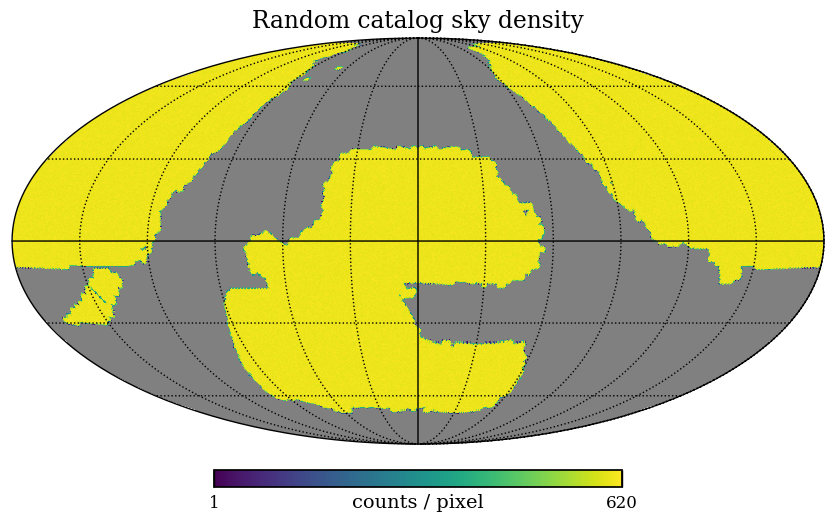

In [8]:
import glob
import numpy as np
from astropy.io import fits
import healpy as hp
import matplotlib.pyplot as plt

# directory containing randoms-*-*.fits
dr9_random_dir = '/global/cfs/cdirs/desi/target/catalogs/dr9/0.49.0/randoms/resolve/'

# find matching files
files = sorted(glob.glob(f"{dr9_random_dir}/randoms-10-0.fits")) #Sample one file first
print(f"Found {len(files)} files")

if len(files) == 0:
    raise FileNotFoundError("No files matched randoms-*.fits")

ra_list = []
dec_list = []

for fn in files:
    with fits.open(fn, memmap=True) as hdul:
        data = hdul[1].data   # assumes catalog table in extension 1
        ra = np.asarray(data["RA"], dtype=float)
        dec = np.asarray(data["DEC"], dtype=float)

        m = np.isfinite(ra) & np.isfinite(dec)
        ra_list.append(ra[m])
        dec_list.append(dec[m])

        hdul.close()

rand_ra = np.concatenate(ra_list)
rand_dec = np.concatenate(dec_list)

print(f"Total points: {len(ra):,}")

# choose map resolution
nside = 128   # increase to 256 for finer map
npix = hp.nside2npix(nside)

# convert RA,DEC -> theta,phi in radians
theta = np.radians(90.0 - dec)   # colatitude
phi = np.radians(ra)             # longitude

pix = hp.ang2pix(nside, theta, phi)

# counts per pixel
density_map = np.bincount(pix, minlength=npix).astype(float)

# optional: mask empty pixels so they plot as blank
density_map[density_map == 0] = hp.UNSEEN

hp.mollview(
    density_map,
    title="Random catalog sky density",
    unit="counts / pixel",
    norm="log",   # useful if density range is wide
    cmap="viridis"
)

hp.graticule()
plt.show()

In [9]:
## Area covered by random catalog
n_occ = np.sum(density_map >= 1)   # or > 0 if not masked with UNSEEN
pix_area_sr = hp.nside2pixarea(nside)   # steradians
area_sr = n_occ * pix_area_sr

print("Covered area [sr]:", area_sr)

pix_area_deg2 = hp.nside2pixarea(nside, degrees=True)
area_deg2 = n_occ * pix_area_deg2

print("Covered area [deg^2]:", area_deg2)

Covered area [sr]: 6.417536457851903
Covered area [deg^2]: 21067.5294352681


In [11]:
## Average number of galaxies per st
f_sky = area_sr / (4*np.pi)
nrandbar_sr = len(ra) / (4*np.pi * f_sky)
nrandbar_deg2 = nbar_sr / ( (180/np.pi)**2 )


print("Average number of randoms per Steridian: ", nrandbar_sr)
print("Average number of randoms per Square Degree: ", nrandbar_deg2)

Average number of randoms per Steridian:  8061806.947228086
Average number of randoms per Square Degree:  2455.7668310831814


## Coverage of the BGS footprint of the DR1 Catalog

In [12]:
## Test using one random catalog
numRand = 0
desiDir = '/global/cfs/cdirs/desi/survey/catalogs/dr1/LSS/iron/LSScats/v1.5pip/'
randomCat = "BGS_ANY_{}_full_HPmapcut.ran.fits".format(numRand)
print(randomCat)
BGS_rand_data = Table.read(desiDir + randomCat)

BGS_ANY_0_full_HPmapcut.ran.fits


In [13]:
# Build coordinate vector with random catalog
BGS_rand_ra = np.asarray(BGS_rand_data['RA'])
BGS_rand_dec = np.asarray(BGS_rand_data['DEC'])
BGS_rand_vecs = radec_to_unitvec(BGS_rand_ra, BGS_rand_dec)

#survey_area_deg2 = 7473 #From DESI DR1   # example, replace with real value
#survey_area_sr = survey_area_deg2 * (np.pi / 180.0)**2
#nrand_bar = len(rand_ra) / survey_area_sr   # randoms per sr

In [14]:
#Build cluster coordinates
ra_cl = np.asarray(rm_tab['RA_x'])
dec_cl = np.asarray(rm_tab['DEC_x'])
z_cl = np.asarray(rm_tab['Z_SPEC_x'])
vecs = radec_to_unitvec(ra_cl, dec_cl)

NameError: name 'rm_tab' is not defined

In [ ]:
nrand_obs = np.zeros(len(rm_tab), dtype=np.int64)
nrand_exp = np.zeros(len(rm_tab), dtype=np.int64)
coverage = np.zeros(len(rm_tab), dtype=np.float64)
nside_rand = 1024
nest = False
rand_map = build_galaxy_healpix_index(rand_ra, rand_dec, nside=nside_rand, nest=nest)['count']

for i in range(len(rm_tab)):
    th_min, th_max = annulus_theta_radians(z_cl[i], Rmin_hMpc=1.5, Rmax_hMpc=10) ## Test with a smaller radius
    annulus_area = spherical_annulus_area_sr(th_min, th_max)

    pix_out = hp.query_disc(nside_rand, vecs[i], th_max, inclusive=False, nest=nest)
    pix_in  = hp.query_disc(nside_rand, vecs[i], th_min, inclusive=False, nest=nest)
    pix_ann = np.setdiff1d(pix_out, pix_in, assume_unique=False)

    nrand_obs[i] = rand_map[pix_ann].sum()
    nrand_exp[i] = nrand_bar * annulus_area
    coverage[i]  = nrand_obs[i]/nrand_exp[i]

rm_tab['coverage'] = coverage

In [ ]:
# How do you know this is the correct coverage. What is the error on the random catalog. 

plt.hist(rm_tab['coverage'], bins=100)
plt.xlabel("Fraction of area covered by the cluster")
plt.ylabel("N")
plt.show()

In [ ]:
##Fix this this is not displaying the images properly

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# --------------------------------------------------
# smoothing helper
# --------------------------------------------------
def make_smooth_healpix_map(ra_deg, dec_deg, nside=128, sigma_deg=0.5):
    m = np.isfinite(ra_deg) & np.isfinite(dec_deg)
    ra_deg = np.asarray(ra_deg[m])
    dec_deg = np.asarray(dec_deg[m])

    theta = np.radians(90.0 - dec_deg)
    phi = np.radians(ra_deg)

    pix = hp.ang2pix(nside, theta, phi)
    counts = np.bincount(pix, minlength=hp.nside2npix(nside)).astype(float)

    original_empty = (counts == 0)
    sigma_rad = np.radians(sigma_deg)
    smooth_map = hp.smoothing(counts, sigma=sigma_rad, verbose=False)
    smooth_map[original_empty] = hp.UNSEEN
    return smooth_map

#----------------
# Convert ra,dec to x,y in mollview
#-------------------
def radec_to_moll_xy(ra_deg, dec_deg):
    ra_deg = np.asarray(ra_deg, dtype=float)
    dec_deg = np.asarray(dec_deg, dtype=float)

    # shift RA into [-180, 180] and flip so RA increases to the left
    lon = (ra_deg + 180.0) % 360.0 - 180.0
    lon = -lon

    lon = np.radians(lon)
    lat = np.radians(dec_deg)

    # solve for auxiliary angle theta
    theta = lat.copy()
    for _ in range(10):
        theta -= (2*theta + np.sin(2*theta) - np.pi*np.sin(lat)) / (2 + 2*np.cos(2*theta))

    x = 2*np.sqrt(2)/np.pi * lon * np.cos(theta)
    y = np.sqrt(2) * np.sin(theta)
    return x, y

# --------------------------------------------------
# build smoothed maps
# --------------------------------------------------
nside = 128
sigma_deg = 1

DR9_smooth_map = make_smooth_healpix_map(rand_ra, rand_dec, nside=nside, sigma_deg=sigma_deg)
BGS_smooth_map = make_smooth_healpix_map(BGS_rand_ra, BGS_rand_dec, nside=nside, sigma_deg=sigma_deg)

# --------------------------------------------------
# Project to 2D Mollweide images
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))
extent = (-2*np.sqrt(2), 2*np.sqrt(2), -np.sqrt(2), np.sqrt(2))

# DR9: smoothed, projected, not drawn automatically
dr9_proj = hp.mollview(
    DR9_smooth_map,
    return_projected_map=True,
    cbar=False,
    notext=True,
    title='',
    hold=True,
    fig=None
)
ax.imshow(dr9_proj, origin='lower', extent=extent, cmap='viridis', alpha=1.0, zorder=1)

# BGS: smoothed, projected, semi-transparent
#bgs_proj = hp.mollview(
#    BGS_smooth_map,
#    return_projected_map=True,
#    cbar=False,
#    notext=True,
#    title='',
#    hold=True,
#    fig=None
#)
#ax.imshow(bgs_proj, origin='lower', extent=extent, cmap='plasma', alpha=0.35, zorder=2)

##Clusters
cl_mask = np.isfinite(ra_cl) & np.isfinite(dec_cl)
x_cl, y_cl = radec_to_moll_xy(ra_cl[cl_mask], dec_cl[cl_mask])
ax.scatter(
    x_cl, y_cl,
    s=8,
    c='red',
    alpha=0.7,
    zorder=3,
    linewidths=0
)


# --------------------------------------------------
# Manual legend
# --------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=plt.cm.viridis(0.8), lw=6, label="DR9 randoms"),
    Line2D([0], [0], color=plt.cm.plasma(0.8), lw=6, alpha=0.6, label="BGS randoms"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=7,
           linestyle='None', label='redMaPPer clusters')
]

# add graticule
hp.graticule()
plt.legend(handles=legend_handles, loc="lower left", frameon=True)
plt.show()

## Mapping DR9 Catalog to SDSS clusters

1. Map the clusters inside the DR9 region (how to filter out)
2. Cuts: Filter out ones that are close to the edge.
3. Construct a file of the total number density.

We want for each cluster the total number of galaxies inside a 10 Mpc/h radius. Think in terms of minimal viable product not in terms of a complete dataset. 

In [ ]:
## Convert the files into healpix and record the density of each pixel. Convert a 10 Mpc/h into pixels. 

In [ ]:
result = count_galaxies_in_annuli(
    cluster_ids=rm_tab['ID'],
    ra_cl=rm_tab['RA_x'],
    dec_cl=rm_tab['DEC_x'],
    z_cl=rm_tab['Z_SPEC_x'],
    ra_gal=bgs_matched['RA_BGS'],
    dec_gal=bgs_matched['DEC_BGS'],
    nside=4096,
    Rmin_hMpc=1.5,
    Rmax_hMpc=10.0,
    verbose_every=1000
)

In [ ]:
rm_tab['Ngal_2D_outer'] = result['ngal_2d']
rm_tab.columns

## What is the distribution of the number density and total number count of environmental galaxies around clusters

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

# --------------------------------------------------
# 1. prepare filtered sample
# --------------------------------------------------
rm_filt = rm_tab[rm_tab['coverage'] > 0.6].copy()

x = np.asarray(rm_filt['LAMBDA'], dtype=float)
z_cl = np.asarray(rm_filt['Z_SPEC_x'], dtype=float)
N_outer = np.asarray(rm_filt['Ngal_2D_outer'], dtype=float)
coverage = np.asarray(rm_filt['coverage'], dtype=float)

print("Clusters kept:", len(rm_filt))
print("Fraction kept:", len(rm_filt) / len(rm_tab))

# --------------------------------------------------
# 2. annulus area and expected random counts
# --------------------------------------------------
annulus_area_sr = np.zeros(len(rm_filt), dtype=float)
annulus_area_deg2 = np.zeros(len(rm_filt), dtype=float)
Nrand_exp = np.zeros(len(rm_filt), dtype=float)

for i in range(len(rm_filt)):
    th_min, th_max = annulus_theta_radians(
        z_cl[i],
        Rmin_hMpc=1.5,
        Rmax_hMpc=10.0
    )
    annulus_area_sr[i] = spherical_annulus_area_sr(th_min, th_max)
    annulus_area_deg2[i] = annulus_area_sr[i] * (180.0 / np.pi)**2
    Nrand_exp[i] = nrandbar_deg2 * annulus_area_deg2[i]

# --------------------------------------------------
# 3. derived quantities
# --------------------------------------------------
Sigma_outer = N_outer / annulus_area_deg2                    # gal / deg^2
Sigma_excess = Sigma_outer - nrandbar_deg2                   # gal / deg^2
Nexcess = N_outer - Nrand_exp                                # total excess in annulus

# optional Poisson-ish significance using random expectation
# useful diagnostic, not exact if counts are weighted/correlated
sig_poisson = Nexcess / np.sqrt(np.clip(Nrand_exp, 1.0, None))

# keep only finite values
mask = (
    np.isfinite(x) &
    np.isfinite(z_cl) &
    np.isfinite(N_outer) &
    np.isfinite(coverage) &
    np.isfinite(annulus_area_deg2) &
    np.isfinite(Nrand_exp) &
    np.isfinite(Sigma_outer) &
    np.isfinite(Sigma_excess) &
    np.isfinite(Nexcess)
)

x = x[mask]
z_cl = z_cl[mask]
coverage = coverage[mask]
annulus_area_deg2 = annulus_area_deg2[mask]
N_outer = N_outer[mask]
Nrand_exp = Nrand_exp[mask]
Sigma_outer = Sigma_outer[mask]
Sigma_excess = Sigma_excess[mask]
Nexcess = Nexcess[mask]
sig_poisson = sig_poisson[mask]

# --------------------------------------------------
# 4. summary statistics
# --------------------------------------------------
def describe(name, arr):
    q = np.percentile(arr, [1, 5, 16, 50, 84, 95, 99])
    print(f"\n{name}")
    print(f"  N      = {len(arr)}")
    print(f"  mean   = {np.mean(arr):.4g}")
    print(f"  std    = {np.std(arr):.4g}")
    print(f"  min    = {np.min(arr):.4g}")
    print(f"  q01    = {q[0]:.4g}")
    print(f"  q05    = {q[1]:.4g}")
    print(f"  q16    = {q[2]:.4g}")
    print(f"  median = {q[3]:.4g}")
    print(f"  q84    = {q[4]:.4g}")
    print(f"  q95    = {q[5]:.4g}")
    print(f"  q99    = {q[6]:.4g}")
    print(f"  max    = {np.max(arr):.4g}")

describe("LAMBDA", x)
describe("Annulus area [deg^2]", annulus_area_deg2)
describe("Observed outer counts N_outer", N_outer)
describe("Expected random counts Nrand_exp", Nrand_exp)
describe("Outer surface density [gal/deg^2]", Sigma_outer)
describe("Excess surface density [gal/deg^2]", Sigma_excess)
describe("Excess counts Nexcess", Nexcess)
describe("Poisson-ish significance", sig_poisson)

print("\nNegative fractions")
print(f"  frac(Sigma_excess < 0) = {np.mean(Sigma_excess < 0):.3f}")
print(f"  frac(Nexcess < 0)      = {np.mean(Nexcess < 0):.3f}")
print(f"  frac(sig_poisson < 0)  = {np.mean(sig_poisson < 0):.3f}")

# --------------------------------------------------
# 5. richness-binned summaries
# --------------------------------------------------
nbins = 8
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), nbins + 1)
bin_centers = np.sqrt(bins[:-1] * bins[1:])

count_bin, _, _ = binned_statistic(x, x, statistic='count', bins=bins)

med_Nouter, _, _ = binned_statistic(x, N_outer, statistic='median', bins=bins)
med_Nrand, _, _ = binned_statistic(x, Nrand_exp, statistic='median', bins=bins)
med_Nexcess, _, _ = binned_statistic(x, Nexcess, statistic='median', bins=bins)

p16_Nexcess, _, _ = binned_statistic(x, Nexcess, statistic=lambda v: np.percentile(v, 16), bins=bins)
p84_Nexcess, _, _ = binned_statistic(x, Nexcess, statistic=lambda v: np.percentile(v, 84), bins=bins)

med_Souter, _, _ = binned_statistic(x, Sigma_outer, statistic='median', bins=bins)
med_Sexcess, _, _ = binned_statistic(x, Sigma_excess, statistic='median', bins=bins)

p16_Sexcess, _, _ = binned_statistic(x, Sigma_excess, statistic=lambda v: np.percentile(v, 16), bins=bins)
p84_Sexcess, _, _ = binned_statistic(x, Sigma_excess, statistic=lambda v: np.percentile(v, 84), bins=bins)

frac_neg_Nexcess = np.full(nbins, np.nan)
frac_neg_Sexcess = np.full(nbins, np.nan)

for i in range(nbins):
    m = (x >= bins[i]) & (x < bins[i+1])
    if np.sum(m) > 0:
        frac_neg_Nexcess[i] = np.mean(Nexcess[m] < 0)
        frac_neg_Sexcess[i] = np.mean(Sigma_excess[m] < 0)

good = count_bin > 5

# --------------------------------------------------
# 6. plots
# --------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)

# histograms
axes[0,0].hist(N_outer, bins=40, alpha=0.8)
axes[0,0].set_xlabel(r'$N_{\rm gal,outer}$')
axes[0,0].set_ylabel('Number of clusters')
axes[0,0].set_title('Observed outer counts')

axes[0,1].hist(Nrand_exp, bins=40, alpha=0.8)
axes[0,1].set_xlabel(r'$N_{\rm rand,exp}$')
axes[0,1].set_ylabel('Number of clusters')
axes[0,1].set_title('Expected random counts')

axes[0,2].hist(Nexcess, bins=50, alpha=0.8)
axes[0,2].axvline(0, color='k', ls='--', lw=1)
axes[0,2].set_xlabel(r'$N_{\rm excess}$')
axes[0,2].set_ylabel('Number of clusters')
axes[0,2].set_title('Excess counts')

axes[1,0].hist(Sigma_outer, bins=40, alpha=0.8)
axes[1,0].set_xlabel(r'$\Sigma_{\rm outer}\ [{\rm gal/deg^2}]$')
axes[1,0].set_ylabel('Number of clusters')
axes[1,0].set_title('Outer surface density')

axes[1,1].hist(Sigma_excess, bins=50, alpha=0.8)
axes[1,1].axvline(0, color='k', ls='--', lw=1)
axes[1,1].set_xlabel(r'$\Sigma_{\rm excess}\ [{\rm gal/deg^2}]$')
axes[1,1].set_ylabel('Number of clusters')
axes[1,1].set_title('Excess surface density')

axes[1,2].hist(sig_poisson, bins=50, alpha=0.8)
axes[1,2].axvline(0, color='k', ls='--', lw=1)
axes[1,2].set_xlabel(r'$N_{\rm excess}/\sqrt{N_{\rm rand,exp}}$')
axes[1,2].set_ylabel('Number of clusters')
axes[1,2].set_title('Poisson-ish significance')

# scatter diagnostics
axes[2,0].scatter(Nrand_exp, N_outer, s=6, alpha=0.35)
mn = min(np.min(Nrand_exp), np.min(N_outer))
mx = max(np.max(Nrand_exp), np.max(N_outer))
axes[2,0].plot([mn, mx], [mn, mx], 'k--', lw=1)
axes[2,0].set_xlabel(r'$N_{\rm rand,exp}$')
axes[2,0].set_ylabel(r'$N_{\rm gal,outer}$')
axes[2,0].set_title(r'Observed vs expected')

axes[2,1].scatter(x, Nexcess, s=6, alpha=0.35)
axes[2,1].axhline(0, color='k', ls='--', lw=1)
axes[2,1].set_xscale('log')
axes[2,1].set_xlabel(r'$\lambda_{\rm RM}$')
axes[2,1].set_ylabel(r'$N_{\rm excess}$')
axes[2,1].set_title('Excess counts vs richness')

axes[2,2].scatter(x, Sigma_excess, s=6, alpha=0.35)
axes[2,2].axhline(0, color='k', ls='--', lw=1)
axes[2,2].set_xscale('log')
axes[2,2].set_xlabel(r'$\lambda_{\rm RM}$')
axes[2,2].set_ylabel(r'$\Sigma_{\rm excess}\ [{\rm gal/deg^2}]$')
axes[2,2].set_title('Excess density vs richness')

plt.show()

# --------------------------------------------------
# 7. binned trend plots
# --------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Nexcess vs lambda
ax[0].errorbar(
    bin_centers[good],
    med_Nexcess[good],
    yerr=[med_Nexcess[good] - p16_Nexcess[good],
          p84_Nexcess[good] - med_Nexcess[good]],
    fmt='o-',
    capsize=3
)
ax[0].axhline(0, color='k', ls='--', lw=1)
ax[0].set_xscale('log')
ax[0].set_xlabel(r'$\lambda_{\rm RM}$')
ax[0].set_ylabel(r'Median $N_{\rm excess}$')
ax[0].set_title('Excess counts vs richness')

# Sigma_excess vs lambda
ax[1].errorbar(
    bin_centers[good],
    med_Sexcess[good],
    yerr=[med_Sexcess[good] - p16_Sexcess[good],
          p84_Sexcess[good] - med_Sexcess[good]],
    fmt='o-',
    capsize=3
)
ax[1].axhline(0, color='k', ls='--', lw=1)
ax[1].set_xscale('log')
ax[1].set_xlabel(r'$\lambda_{\rm RM}$')
ax[1].set_ylabel(r'Median $\Sigma_{\rm excess}$ [{\rm gal/deg^2}]')
ax[1].set_title('Excess density vs richness')

plt.show()

# --------------------------------------------------
# 8. print compact bin summary
# --------------------------------------------------
print("\nBin summary:")
for i in range(nbins):
    if good[i]:
        print(
            f"bin {i:02d}: "
            f"lambda~{bin_centers[i]:6.2f}, "
            f"N={int(count_bin[i]):4d}, "
            f"med(N_outer)={med_Nouter[i]:7.3f}, "
            f"med(Nrand)={med_Nrand[i]:7.3f}, "
            f"med(Nexcess)={med_Nexcess[i]:7.3f}, "
            f"frac_neg(Nexcess)={frac_neg_Nexcess[i]:.3f}, "
            f"frac_neg(Sigma_excess)={frac_neg_Sexcess[i]:.3f}"
        )

## Correlations

* Map correlations between number count of galaxies vs richness of the cluster (spec. vs redMaPPer richness)
* Determine if scaling such as by R_lambda changes at all this result.
* Determine if we can find a positive/negative trend.
* Error analysis. Sources of error: photometric redshift weighting, pixel resolution. 

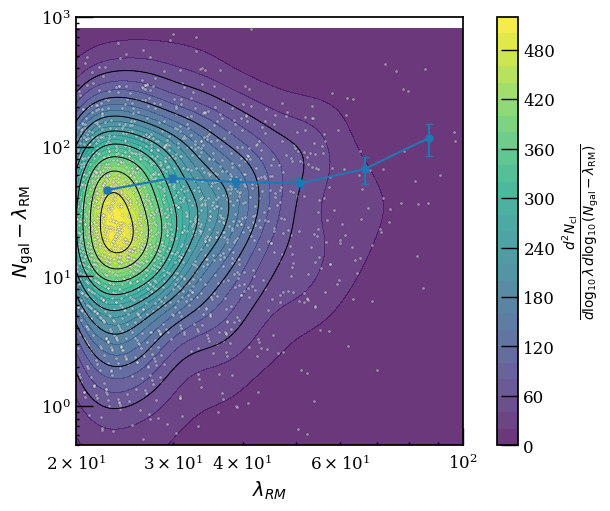

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, binned_statistic

fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)
x = np.asarray(rm_tab['LAMBDA'])
y = np.asarray(rm_tab['Ngal_2D_outer'] - rm_tab['LAMBDA'])

# remove invalid values for log scale
mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# log space for KDE
lx = np.log10(x)
ly = np.log10(y)

kde = gaussian_kde([lx, ly], bw_method=0.35)

# grid
xgrid = np.linspace(lx.min(), lx.max(), 200)
ygrid = np.linspace(ly.min(), ly.max(), 200)
xx, yy = np.meshgrid(xgrid, ygrid)

coords = np.vstack([xx.ravel(), yy.ravel()])
density = kde(coords).reshape(xx.shape)
density *= len(xx)

X = 10**xx
Y = 10**yy

# ---------------------------
# choose lambda bins
# ---------------------------
nbins = 8
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), nbins + 1)

# bin centers
bin_centers = np.sqrt(bins[:-1] * bins[1:])   # geometric centers for log bins

# ---------------------------
# compute binned mean
# ---------------------------
mean_y, _, _ = binned_statistic(x, y, statistic='mean', bins=bins)
std_y, _, _  = binned_statistic(x, y, statistic='std', bins=bins)
count_y, _, _ = binned_statistic(x, y, statistic='count', bins=bins)

# standard error on the mean
sem_y = std_y / np.sqrt(count_y)

# only keep bins with enough points
good = count_y > 3

# ---------------------------
# plot
# ---------------------------

# faint scatter in background
ax.scatter(x, y, s=4, alpha=0.12)

# binned trend with errorbars
ax.errorbar(
    bin_centers[good],
    mean_y[good],
    yerr=sem_y[good],
    fmt='o-',
    capsize=3,
    lw=1.5,
    ms=5,
    label='Binned mean'
)

# KDE filled contours
cf = ax.contourf(X, Y, density, levels=25, cmap='viridis', alpha=0.8)

# KDE contour lines
ax.contour(X, Y, density, levels=8, colors='black', linewidths=0.7)

# scatter overlay
ax.scatter(x, y, s=5, color='white', edgecolor='black', linewidth=0.2, alpha=0.4)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\lambda_{RM}$')
ax.set_ylabel(r'$N_{\rm gal} - \lambda_{\rm RM}$')

#fig.colorbar(cf, ax=ax, label='KDE density')
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r'$\frac{d^2N_{\rm cl}}{d\log_{10}\lambda\,d\log_{10}(N_{\rm gal}-\lambda_{\rm RM})}$')

plt.xlim([20,100]); plt.ylim([5e-1,1e3])
plt.show()

In [65]:
## Test for edge cases. Edge of map. Pixel resolution. 

In [66]:
import numpy as np
import healpy as hp

def ang2vec_ra_dec(ra_deg, dec_deg):
    theta = np.radians(90.0 - dec_deg)   # colatitude
    phi = np.radians(ra_deg)
    return hp.ang2vec(theta, phi)

def annulus_pixels_disc(nside, vec, r_in_rad, r_out_rad, nest=False):
    pix_out = hp.query_disc(nside, vec, r_out_rad, inclusive=False, nest=nest)
    pix_in  = hp.query_disc(nside, vec, r_in_rad,  inclusive=False, nest=nest)
    annulus = np.setdiff1d(pix_out, pix_in, assume_unique=False)
    return annulus

def edge_fraction_for_cluster(ra, dec, nside, r_in_rad, r_out_rad, valid_mask, nest=False):
    vec = ang2vec_ra_dec(ra, dec)
    annulus = annulus_pixels_disc(nside, vec, r_in_rad, r_out_rad, nest=nest)

    if len(annulus) == 0:
        return np.nan, annulus

    n_total = len(annulus)
    n_edge = np.sum(~valid_mask[annulus])
    frac_edge = n_edge / n_total
    return frac_edge, annulus


def spherical_annulus_area_sr(theta_min, theta_max):
    return 2.0 * np.pi * (np.cos(theta_min) - np.cos(theta_max))

In [67]:
## Radial dependence of the annuli

### Removing the random catalogs
Removing the random catalogs in the DR9 catalog. 


Found 1 files
Total points: 51,736,940


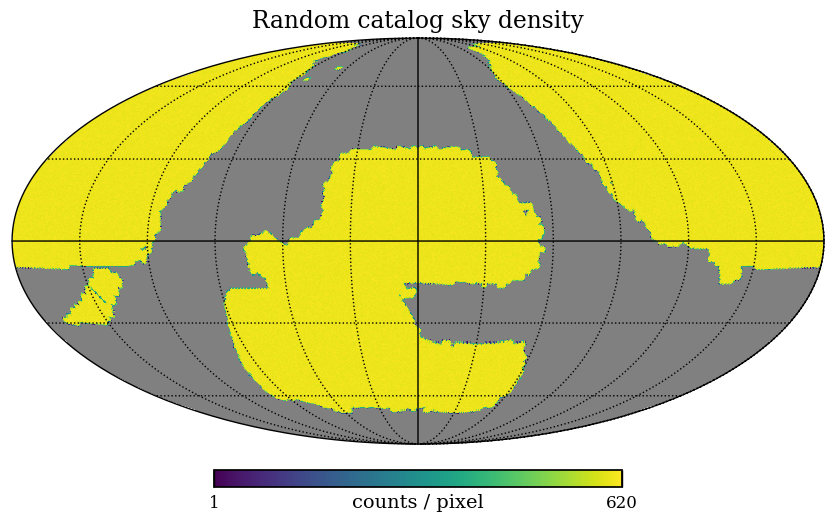

### Test for 80% fraction. 

Remove clusters with coverage < 60% and re-run the galaxy number density analysis. 

Percentage of clusters with enough coverage:  0.7980412524113369


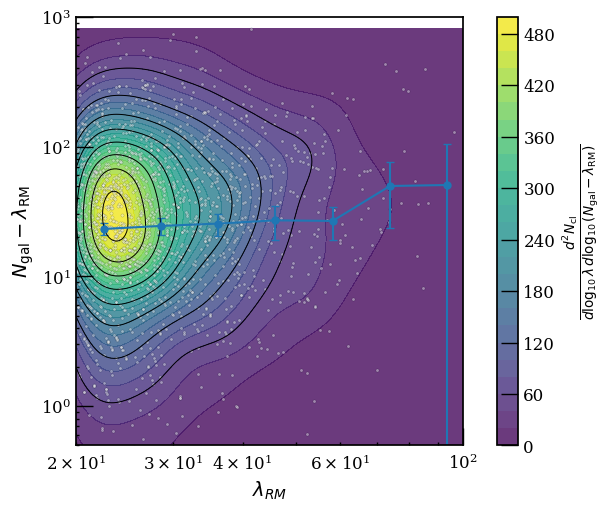

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, binned_statistic

fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)

rm_filt = rm_tab[np.where(rm_tab['coverage']>0.6)]
ra_cl = np.asarray(rm_filt['RA_x'])
dec_cl = np.asarray(rm_filt['DEC_x'])
z_cl = np.asarray(rm_filt['Z_SPEC_x'])
vecs = radec_to_unitvec(ra_cl, dec_cl)
print("Percentage of clusters with enough coverage: ", len(rm_filt)/len(rm_tab))

#Number of expected randoms
nrand_exp = np.zeros(len(rm_filt))
for i in range(len(rm_filt)):
    th_min, th_max = annulus_theta_radians(z_cl[i], Rmin_hMpc=1.5, Rmax_hMpc=10) ## Test with a smaller radius
    annulus_area = spherical_annulus_area_sr(th_min, th_max)
    nrand_exp[i] = nrand_bar * annulus_area


x = np.asarray(rm_filt['LAMBDA']) 
y = np.asarray(rm_filt['Ngal_2D_outer'] - rm_filt['LAMBDA'])

# remove invalid values for log scale
mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# log space for KDE
lx = np.log10(x)
ly = np.log10(y)

kde = gaussian_kde([lx, ly], bw_method=0.35)

# grid
xgrid = np.linspace(lx.min(), lx.max(), 200)
ygrid = np.linspace(ly.min(), ly.max(), 200)
xx, yy = np.meshgrid(xgrid, ygrid)

coords = np.vstack([xx.ravel(), yy.ravel()])
density = kde(coords).reshape(xx.shape)
density *= len(xx)

X = 10**xx
Y = 10**yy

# ---------------------------
# choose lambda bins
# ---------------------------
nbins = 9
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), nbins + 1)

# bin centers
bin_centers = np.sqrt(bins[:-1] * bins[1:])   # geometric centers for log bins

# ---------------------------
# compute binned mean
# ---------------------------
logmean_y, _, _ = binned_statistic(x, np.log10(y), statistic='mean', bins=bins)
mean_y = 10**logmean_y
std_y, _, _  = binned_statistic(x, y, statistic='std', bins=bins)
count_y, _, _ = binned_statistic(x, y, statistic='count', bins=bins)

# standard error on the mean
sem_y = std_y / np.sqrt(count_y)

# only keep bins with enough points
good = count_y > 3

# ---------------------------
# plot
# ---------------------------

# faint scatter in background
ax.scatter(x, y, s=4, alpha=0.12)

# binned trend with errorbars
ax.errorbar(
    bin_centers[good],
    mean_y[good],
    yerr=sem_y[good],
    fmt='o-',
    capsize=3,
    lw=1.5,
    ms=5,
    label='Binned mean'
)

# KDE filled contours
cf = ax.contourf(X, Y, density, levels=25, cmap='viridis', alpha=0.8)

# KDE contour lines
ax.contour(X, Y, density, levels=8, colors='black', linewidths=0.7)

# scatter overlay
ax.scatter(x, y, s=5, color='white', edgecolor='black', linewidth=0.2, alpha=0.4)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\lambda_{RM}$')
ax.set_ylabel(r'$N_{\rm gal} - \lambda_{\rm RM}$')

#fig.colorbar(cf, ax=ax, label='KDE density')
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r'$\frac{d^2N_{\rm cl}}{d\log_{10}\lambda\,d\log_{10}(N_{\rm gal}-\lambda_{\rm RM})}$')

plt.xlim([20,100]); plt.ylim([5e-1,1e3])
plt.show()

## Recompute after removing randoms

Percentage of clusters with enough coverage: 0.7980412524113369
Number of clusters after positive-y cut: 5378


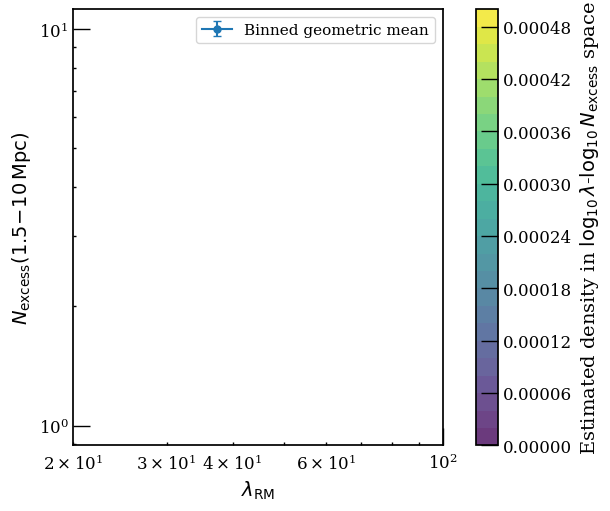

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, binned_statistic

fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)

# ---------------------------
# filter clusters
# ---------------------------
rm_filt = rm_tab[rm_tab['coverage'] > 0.6]

ra_cl  = np.asarray(rm_filt['RA_x'])
dec_cl = np.asarray(rm_filt['DEC_x'])
z_cl   = np.asarray(rm_filt['Z_SPEC_x'])

print("Percentage of clusters with enough coverage:", len(rm_filt)/len(rm_tab))

# ---------------------------
# annulus area and expected random counts
# ---------------------------
annulus_area_deg2 = np.zeros(len(rm_filt))
nrand_exp = np.zeros(len(rm_filt))

for i in range(len(rm_filt)):
    th_min, th_max = annulus_theta_radians(
        z_cl[i],
        Rmin_hMpc=1.5,
        Rmax_hMpc=10.0
    )
    annulus_area_sr = spherical_annulus_area_sr(th_min, th_max)
    annulus_area_deg2[i] = annulus_area_sr * (180.0 / np.pi)**2
    nrand_exp[i] = nrandbar_deg2 * annulus_area_deg2[i]

# ---------------------------
# x and y
# x = richness
# y = excess number of galaxies in the annulus
# ---------------------------
x = np.asarray(rm_filt['LAMBDA'])
N_outer = np.asarray(rm_filt['Ngal_2D_outer']) - x
y = N_outer - nrand_exp

# keep only positive finite values for log-log plot
mask = (x > 0) & np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

print("Number of clusters after cut:", len(x))

# ---------------------------
# KDE in log-log space
# ---------------------------
if len(x) > 1:
    lx = np.log10(x)
    ly = y

    kde = gaussian_kde([lx, ly], bw_method=0.35)

    xgrid = np.linspace(lx.min(), lx.max(), 200)
    ygrid = np.linspace(ly.min(), ly.max(), 200)
    xx, yy = np.meshgrid(xgrid, ygrid)

    coords = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(coords).reshape(xx.shape)

    X = 10**xx
    #Y = 10**yy
    Y = yy
else:
    density = None

# ---------------------------
# choose lambda bins
# ---------------------------
nbins = 9
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), nbins + 1)
bin_centers = np.sqrt(bins[:-1] * bins[1:])

# ---------------------------
# geometric mean relation in log space
# ---------------------------
mean_y, _, _ = binned_statistic(x, y, statistic='mean', bins=bins)
std_y, _, _  = binned_statistic(x, y, statistic='std', bins=bins)
count_y, _, _   = binned_statistic(x, y, statistic='count', bins=bins)

sem_logy = std_y / np.sqrt(count_y)

y_low = (mean_y - sem_logy)
y_high = (mean_y + sem_logy)

yerr_lower = mean_y - y_low
yerr_upper = y_high - mean_y

good = count_y > 3

# ---------------------------
# plot
# ---------------------------
ax.scatter(x, y, s=4, alpha=0.12)

if density is not None:
    cf = ax.contourf(X, Y, density, levels=25, cmap='viridis', alpha=0.8)
    ax.contour(X, Y, density, levels=8, colors='black', linewidths=0.7)
    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(r'Estimated density in $\log_{10}\lambda$-$\log_{10}N_{\rm excess}$ space')

ax.errorbar(
    bin_centers[good],
    mean_y[good],
    yerr=[yerr_lower[good], yerr_upper[good]],
    fmt='o-',
    capsize=3,
    lw=1.5,
    ms=5,
    label='Binned geometric mean'
)

ax.scatter(
    x, y,
    s=5,
    color='white',
    edgecolor='black',
    linewidth=0.2,
    alpha=0.4
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\lambda_{\rm RM}$')
ax.set_ylabel(r'$N_{\rm excess}(1.5\!-\!10\,{\rm Mpc})$')

ax.set_xlim([20, 100])
# ax.set_ylim([1, 1e3])   # tune if needed
ax.legend()

plt.show()